In [1]:
import os
import numpy as np
from Python_Scripts.ST import *
import Python_Scripts.QuantBacktester as qd
import Python_Scripts.mass as mk
from scipy import stats, signal
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [2]:
wSize = [45, 60, 90, 100]

excelReaderfObj = qd.ExcelInputReader()
universeFilePath = r'D:\Linear Model\data\Universe\TradingDays.xlsx'  #'G:/.shortcut-targets-by-id/0B7f_UMMZHM_JNXljMVVXY2VPcHM/Investment Research_N/Manu/Universe/TradingDays.xlsx'
allTradingDatesDf = excelReaderfObj.getTradingDatesDataFrame(excelFile=universeFilePath, sheetName='Sheet1')
allTradingDatesDf.reset_index(drop=True, inplace=True)
ricDict = {
    '.NSEI': r'D:\Linear Model\data\Universe\INDTradingDays.xlsx'}  #'G:/.shortcut-targets-by-id/0B7f_UMMZHM_JNXljMVVXY2VPcHM/Investment Research_N/Manu/Universe/INDTradingDays.xlsx'}
priceDf = qd.UtilsQB().setDatFrame(allTradingDatesDf, ricDict)
#mainFolderPath = r'D:\Linear Model\data\RSI\Final'
mainFolderPath = os.path.join("data", "RSI", "Final", "NSEI")
freq = 'W'
existingFilePath = os.path.join(mainFolderPath, f"{freq}_allRebal.xlsx")
currentDf = excelReaderfObj.getDataFrame(existingFilePath, rowsToSkip=0, columnsToSkip=0)
currentDf.set_index('Date', inplace=True)
niftyCloseDf = priceDf[3][['.NSEI']]

In [3]:
from Python_Scripts import tsa, arma


def getDp(niftyCloseDf, dte, w):
    sim = mk.Match(niftyCloseDf.loc[niftyCloseDf.first_valid_index():], dte, windowSize=w, threshold=0.9)
    dp = sim.getDates()
    return dp


def getSimulateDf(niftyCloseDf, dte, w, dp, rep=35):
    qRoi = niftyCloseDf.iloc[niftyCloseDf.index.get_loc(dp) - 13:][:w + 14]
    frCoff = tsa.FractionEstimate(np.log(qRoi), numLag=14, interval=0.1, confidence=0.95, tolerance=1e-4).getBest()
    if frCoff != 1:
        qFD = tsa.FractionalDifferencing(numLag=14, fraction=frCoff, tolerance=1e-4)
        qFR = qFD.getDifferencedSeries(np.log(qRoi))

        # print(qFR)
        qFRIC = arma.ModelSelection(qFR.values.flatten(), 5, 5).getICseries()
        qFRIC.sort_values("AIC", inplace=True)
        # print(qFRIC)
        p, q = qFRIC.loc[qFRIC.index[0]]['p'], qFRIC.loc[qFRIC.index[0]]['q']

        # print(p,q)
        mod = arma.Model(qFR, p=int(p), q=int(q))
        mod.getParams()

        oRoi = niftyCloseDf.loc[:dte][-15:]
        oFD = tsa.FractionalDifferencing(numLag=14, fraction=frCoff, tolerance=1e-4)
        oFR = oFD.getDifferencedSeries(np.log(oRoi))

        sims = arma.SimulateFD(mod, init_Val=oFR.iloc[0].values.flatten(), repetition=rep).getFDValues()
        simPrice = []
        for i in range(rep):
            simPrice.append(tsa.BackOperation(niftyCloseDf.loc[:dte][-14:].values.flatten(), sims.iloc[:, i],
                                              fraction=frCoff).getPrediction().values.flatten())
        simulatedPriceDf = pd.DataFrame(simPrice).T
        ci = niftyCloseDf.index.get_loc(dte)
        simulatedPriceDf.index = niftyCloseDf.iloc[ci - 13:ci + 23].index

        return p, q, qRoi, qFR, qFRIC, oRoi, oFR, simulatedPriceDf
    else:
        return -999


def getBeta(niftyCloseDf, dte, w, dp, rep=35):
    qRoi = niftyCloseDf.iloc[niftyCloseDf.index.get_loc(dp) - 13:][:w + 14]
    frCoff = tsa.FractionEstimate(np.log(qRoi), numLag=14, interval=0.1, confidence=0.95, tolerance=1e-4).getBest()
    if frCoff != 1:
        qFD = tsa.FractionalDifferencing(numLag=14, fraction=frCoff, tolerance=1e-4)
        qFR = qFD.getDifferencedSeries(np.log(qRoi))

        # print(qFR)
        # qFRIC = arma.ModelSelection(qFR.values.flatten(),5,5).getICseries()
        # qFRIC.sort_values("AIC", inplace= True)
        # # print(qFRIC)
        # p, q= qFRIC.loc[qFRIC.index[0]]['p'], qFRIC.loc[qFRIC.index[0]]['q']

        # print(p,q)
        mod = arma.Model(qFR, p=int(8), q=int(0))
        params = mod.getParams()

        return params.loc['ar.L1']['Coefficient']
    else:
        return -999


def remove_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return series[(series >= lower_bound) & (series <= upper_bound)]


def getComp(niftyCloseDf, predictionDf):
    mCol = niftyCloseDf.columns[0]
    tmpDf = niftyCloseDf.loc[predictionDf.index][[mCol]]
    tmpDf.loc[predictionDf.index, 'Prediction'] = predictionDf.values

    mean_mCol = tmpDf[mCol].pct_change(1).mean()
    std_mCol = tmpDf[mCol].pct_change(1).std()

    mean_Prediction = tmpDf['Prediction'].pct_change(1).mean()
    std_Prediction = tmpDf['Prediction'].pct_change(1).std()

    # Correlation
    correlation = tmpDf[mCol].corr(tmpDf['Prediction'])

    ret_mCol = tmpDf.loc[tmpDf.index[-1]][mCol] / tmpDf.loc[tmpDf.index[0]][mCol] - 1
    ret_Prediction = tmpDf.loc[tmpDf.index[-1]]['Prediction'] / tmpDf.loc[tmpDf.index[0]]['Prediction'] - 1

    return mean_mCol, mean_Prediction, ret_mCol, ret_Prediction, std_mCol, std_Prediction, correlation, tmpDf


def getCompBeta(niftyCloseDf, dte):
    mCol = niftyCloseDf.columns[0]
    tmpDf = niftyCloseDf[[mCol]]
    currentRet = tmpDf.loc[dte][mCol] / tmpDf.iloc[tmpDf.index.get_loc(dte) - 13][mCol] - 1
    fwdRet = tmpDf.iloc[tmpDf.index.get_loc(dte) + 13][mCol] / tmpDf.loc[dte][mCol] - 1

    return currentRet, fwdRet

In [4]:
testingPeriod = currentDf.loc['2014-01-03':'2024-06-07'].index
resultDf2 = pd.DataFrame(index=testingPeriod, columns=['Mean_Act', 'Mean_Pred',
                                                       'Ret_Act', 'Ret_Pred',
                                                       'Std_Act', 'Std_Pred',
                                                       'Corr'])
resultDf2 = pd.DataFrame(index=testingPeriod, columns=['Beta', 'Beta_Max', 'PastRet', 'FwdRet'])
for dte in testingPeriod:
    dpDf = getDp(niftyCloseDf, dte, 45)
    if dpDf.shape[0] > 0:
        simPrices = []
        for dp in dpDf.index[0:1]:
            res = getSimulateDf(niftyCloseDf, dte, 45, dp, 100)
            if res != -999:
                meanPred = res[7].apply(lambda row: remove_outliers_iqr(row).mean(), axis=1)
                # meanPred = res[7].mean(1)
                predictionDf = meanPred.iloc[meanPred.index.get_loc(dte):]
                res2 = getComp(niftyCloseDf, predictionDf)
                for i in range(0, len(resultDf2.columns)): resultDf2.loc[dte][resultDf2.columns[i]] = res2[i]
    print(dte)

2014-01-03 00:00:00
2014-01-10 00:00:00
2014-01-17 00:00:00
2014-01-24 00:00:00
2014-01-31 00:00:00
2014-02-07 00:00:00
2014-02-14 00:00:00
2014-02-21 00:00:00
2014-02-28 00:00:00
2014-03-07 00:00:00
2014-03-14 00:00:00
2014-03-22 00:00:00
2014-03-28 00:00:00
2014-04-04 00:00:00
2014-04-11 00:00:00
2014-04-17 00:00:00
2014-04-25 00:00:00
2014-05-02 00:00:00
2014-05-09 00:00:00
2014-05-16 00:00:00
2014-05-23 00:00:00
2014-05-30 00:00:00
2014-06-06 00:00:00
2014-06-13 00:00:00
2014-06-20 00:00:00
2014-06-27 00:00:00
2014-07-04 00:00:00
2014-07-11 00:00:00
2014-07-18 00:00:00
2014-07-25 00:00:00
2014-08-01 00:00:00
2014-08-08 00:00:00
2014-08-14 00:00:00
2014-08-22 00:00:00
2014-08-28 00:00:00
2014-09-05 00:00:00
2014-09-12 00:00:00
2014-09-19 00:00:00
2014-09-26 00:00:00
2014-10-01 00:00:00
2014-10-10 00:00:00
2014-10-17 00:00:00
2014-10-23 00:00:00
2014-10-31 00:00:00
2014-11-07 00:00:00
2014-11-14 00:00:00
2014-11-21 00:00:00
2014-11-28 00:00:00
2014-12-05 00:00:00
2014-12-12 00:00:00


In [5]:
for dte in testingPeriod:
    dpDf = getDp(niftyCloseDf,dte,90)
    if dpDf.shape[0] > 0:
        resAvg = []
        for dp in dpDf.index[0:5]:
            res = getBeta(niftyCloseDf,dte,90, dp, 100)
            if res != -999:
                resAvg.append(res)
        res2 = getCompBeta(niftyCloseDf,dte)
        resultDf2.loc[dte]['Beta']  = np.mean(resAvg)
        resultDf2.loc[dte]['Beta_Max']  = np.max(resAvg)
        resultDf2.loc[dte]['PastRet']  = res2[0]
        resultDf2.loc[dte]['FwdRet']  = res2[1]
    print(dte)

2014-01-03 00:00:00
2014-01-10 00:00:00
2014-01-17 00:00:00
2014-01-24 00:00:00
2014-01-31 00:00:00
2014-02-07 00:00:00
2014-02-14 00:00:00
2014-02-21 00:00:00
2014-02-28 00:00:00
2014-03-07 00:00:00
2014-03-14 00:00:00
2014-03-22 00:00:00
2014-03-28 00:00:00
2014-04-04 00:00:00
2014-04-11 00:00:00
2014-04-17 00:00:00
2014-04-25 00:00:00
2014-05-02 00:00:00
2014-05-09 00:00:00
2014-05-16 00:00:00
2014-05-23 00:00:00
2014-05-30 00:00:00
2014-06-06 00:00:00
2014-06-13 00:00:00
2014-06-20 00:00:00
2014-06-27 00:00:00
2014-07-04 00:00:00
2014-07-11 00:00:00
2014-07-18 00:00:00
2014-07-25 00:00:00
2014-08-01 00:00:00
2014-08-08 00:00:00
2014-08-14 00:00:00
2014-08-22 00:00:00
2014-08-28 00:00:00
2014-09-05 00:00:00
2014-09-12 00:00:00
2014-09-19 00:00:00
2014-09-26 00:00:00
2014-10-01 00:00:00
2014-10-10 00:00:00
2014-10-17 00:00:00
2014-10-23 00:00:00
2014-10-31 00:00:00
2014-11-07 00:00:00
2014-11-14 00:00:00
2014-11-21 00:00:00
2014-11-28 00:00:00
2014-12-05 00:00:00
2014-12-12 00:00:00


In [6]:
resultDf2_clean = resultDf2.dropna()

resultDf2_clean['Diff'] = resultDf2_clean['FwdRet'] - resultDf2_clean['PastRet']

In [7]:
from scipy.stats import percentileofscore

In [8]:
def average_every_5_percentile(df):
    # percentile_averages = pd.DataFrame(index = range(5,105,5), columns = df.columns)

    for column in df.columns:
        # Drop NaN values
        col_clean = df[column].dropna()

        # Calculate averages for each 5-percentile range
        # ranges = {}
        # for i in range(0, 100, 5):
            # lower_value = np.percentile(col_clean, i)
            # upper_value = np.percentile(col_clean, i + 5)

            # Filter the column values within the current percentile range
            # within_percentiles = col_clean[(col_clean >= lower_value) & (col_clean < upper_value)]

            # Calculate the mean within this range
            # ranges[f'{i}-{i + 5}%'] = within_percentiles.mean()
            # percentile_averages.loc[i+5][column]  = within_percentiles.mean()
            # percentile_averages.loc[i+5][column + 'Max']  = within_percentiles.max()
            # percentile_averages.loc[i+5][column + 'Min']  = within_percentiles.min()

        percentile_column = df[column].apply(lambda x: percentileofscore(col_clean, x) if not pd.isnull(x) else np.nan)

            # Add the percentile column to the DataFrame
        df[f'{column}_percentile'] = percentile_column

        bins = list(range(0, 101, 5))  # [0, 5, 10, ..., 95, 100]
        labels = [f'{i}-{i+5}%' for i in range(0, 100, 5)]
        df[f'{column}_percentile_bin'] = pd.cut(df[f'{column}_percentile'], bins=bins, include_lowest=True)


        # percentile_averages[column] = ranges

    return df

In [9]:
percentile_averages = average_every_5_percentile(resultDf2_clean)

In [10]:
percentile_averages

,Beta,Beta_Max,PastRet,FwdRet,Diff,Beta_percentile,Beta_percentile_bin,Beta_Max_percentile,Beta_Max_percentile_bin,PastRet_percentile,PastRet_percentile_bin,FwdRet_percentile,FwdRet_percentile_bin,Diff_percentile,Diff_percentile_bin
Date,,,,,,,,,,,,,,,
2014-01-03,0.316137,0.322563,0.009172,0.020576,0.011404,24.303797,"(20.0, 25.0]",23.291139,"(20.0, 25.0]",45.822785,"(45.0, 50.0]",61.518987,"(60.0, 65.0]",60.506329,"(60.0, 65.0]"
2014-03-14,0.001906,0.002744,0.042311,0.062088,0.019777,17.974684,"(15.0, 20.0]",18.481013,"(15.0, 20.0]",87.341772,"(85.0, 90.0]",93.670886,"(90.0, 95.0]",67.088608,"(65.0, 70.0]"
2014-03-22,0.001851,0.002584,0.041009,0.05824,0.017231,17.721519,"(15.0, 20.0]",17.468354,"(15.0, 20.0]",86.329114,"(85.0, 90.0]",91.392405,"(90.0, 95.0]",64.050633,"(60.0, 65.0]"
2014-03-28,0.000151,0.001479,0.002897,0.032932,0.030035,10.379747,"(10.0, 15.0]",12.911392,"(10.0, 15.0]",38.481013,"(35.0, 40.0]",74.936709,"(70.0, 75.0]",74.683544,"(70.0, 75.0]"
2014-04-04,0.841284,0.841284,0.026103,0.003122,-0.022981,97.215190,"(95.0, 100.0]",86.329114,"(85.0, 90.0]",70.886076,"(70.0, 75.0]",39.493671,"(35.0, 40.0]",30.886076,"(30.0, 35.0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-03-15,0.36153,0.75073,-0.007883,0.022265,0.030148,26.075949,"(25.0, 30.0]",64.683544,"(60.0, 65.0]",25.822785,"(25.0, 30.0]",63.544304,"(60.0, 65.0]",74.936709,"(70.0, 75.0]"
2024-03-22,0.440641,0.625149,-0.013785,0.007954,0.021738,30.632911,"(30.0, 35.0]",35.443038,"(35.0, 40.0]",20.759494,"(20.0, 25.0]",46.835443,"(45.0, 50.0]",69.620253,"(65.0, 70.0]"
2024-03-28,0.574588,0.7739,-0.007409,-0.008058,-0.000649,45.063291,"(45.0, 50.0]",70.126582,"(70.0, 75.0]",26.329114,"(25.0, 30.0]",25.822785,"(25.0, 30.0]",50.126582,"(50.0, 55.0]"


In [11]:
X = percentile_averages.groupby('Ret_Act_percentile_bin')['Ret_Pred'].mean()
y = percentile_averages.groupby('Ret_Act_percentile_bin')['Ret_Act'].mean()

KeyError: 'Ret_Act_percentile_bin'

In [12]:
X = percentile_averages.groupby('Diff_percentile_bin')['Beta'].mean()
y = percentile_averages.groupby('Diff_percentile_bin')['Diff'].mean()

In [14]:
X = percentile_averages['Beta_Max']
y = percentile_averages['Diff']

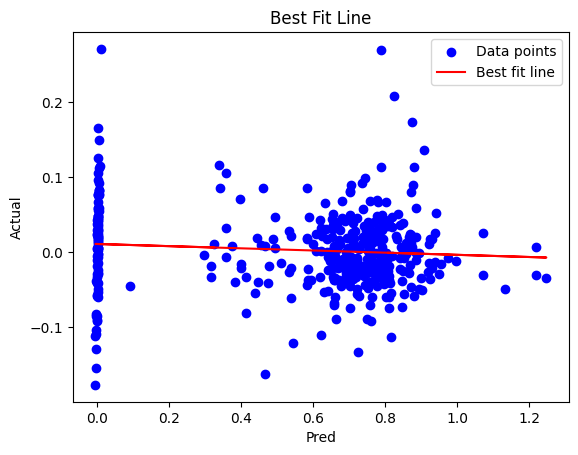

In [15]:
model = LinearRegression()
model.fit(X.values.reshape(-1, 1), y.values)

# Predict y values using the model
y_pred = model.predict(X.values.reshape(-1, 1))

# Plot the data points
plt.scatter(X, y, color='blue', label='Data points')

# Plot the best fit line
plt.plot(X, y_pred, color='red', label='Best fit line')

# Adding labels and title
plt.xlabel('Pred')
plt.ylabel('Actual')
plt.title('Best Fit Line')
plt.legend()

# Show the plot
plt.show()

In [16]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Separate the columns into variables
X = percentile_averages['Mean_Pred'].values.reshape(-1, 1)  # Independent variable
y = percentile_averages['Mean_Act'].values  # Dependent variable
# Perform linear regression
model = LinearRegression()
model.fit(X, y)

# Predict y values using the model
y_pred = model.predict(X)

# Plot the data points
plt.scatter(percentile_averages['Mean_Pred'], percentile_averages['Mean_Act'], color='blue', label='Data points')

# Plot the best fit line
plt.plot(percentile_averages['Mean_Pred'], y_pred, color='red', label='Best fit line')

# Adding labels and title
plt.xlabel('Pred')
plt.ylabel('Actual')
plt.title('Best Fit Line')
plt.legend()

# Show the plot
plt.show()



KeyError: 'Mean_Pred'

In [18]:
from Python_Scripts import mass
sim = mk.Match(priceDf[3][['.NSEI']].loc[priceDf[3]['.NSEI'].first_valid_index():], '2020-06-08', windowSize=wSize[0],
               threshold=0.9)

# ans = sim.getMatchIndex()
ans_idx, ans_date = sim.getMatchIndex()
# remove indices that leave < windowSize observations ahead
valid_mask = ans_idx + sim.win < len(sim.data)
ans_idx = ans_idx[valid_mask]
ans_date = ans_date[valid_mask]
# now safe
reg = pd.DataFrame({'idx': ans_idx,
                    'start': ans_date,
                    'end': sim.data.iloc[ans_idx + sim.win].index,
                    'dp': sim.getDPValues()[valid_mask]})
reg = sim.getRegime()

dp = sim.getDates()

import Python_Scripts.tsa as tsa

qRoi = niftyCloseDf.iloc[niftyCloseDf.index.get_loc(dp) - 13:][:90 + 14]

frCoff = tsa.FractionEstimate(qRoi, numLag=14, interval=0.1, confidence=0.95, tolerance=1e-4).getBest()
print(frCoff)

qFD = tsa.FractionalDifferencing(numLag=14, fraction=frCoff, tolerance=1e-4)
qFR = qFD.getDifferencedSeries(qRoi)

import Python_Scripts.arma as arma

qFR12IC = arma.ModelSelection(qFR.values.flatten(), 14, 14).getICseries()
qFR12IC.sort_values("AIC").head()
mod12 = arma.Model(qFR, p=1, q=0)
params = mod12.getParams()
rep = 35

oRoi = priceDf[3][['.NSEI']].loc[:'2020-06-08'][-15:]
oFD = tsa.FractionalDifferencing(numLag=14, fraction=frCoff, tolerance=1e-4)
oFR = oFD.getDifferencedSeries(np.log(oRoi))

sims12 = arma.SimulateFD(mod12, init_Val=oFR.iloc[0].values.flatten(), repetition=rep).getFDValues()
fig, ax = plt.subplots(figsize=(24, 6))
simPrice = []
for i in range(rep):
    simPrice.append(
        tsa.BackOperation(priceDf[3][['.NSEI']].loc[:'2020-06-08'][-14:].values.flatten(), sims12.iloc[:, i],
                          fraction=frCoff).getPrediction().values.flatten())
pd.DataFrame(simPrice).T.plot(ax=ax, color='r')
ax.get_legend().remove()


dp shape: (6075, 3)
idx shape: (6075,)
dp shape: (6075, 3)
idx shape: (6075,)


IndexError: positional indexers are out-of-bounds